In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.tree import export_text
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error


sns.set_theme(style="whitegrid")

Data Loaded: 158 rows
Target: 'age_gap'
Initial numeric features: 93


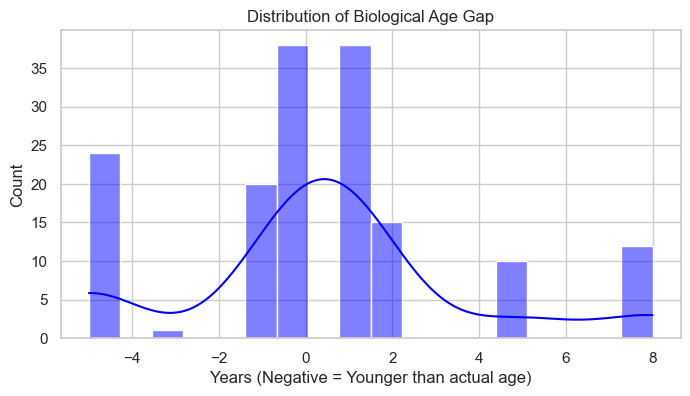

In [ ]:
df = pd.read_csv('data/Anovator_Biological_Master.csv')

# Defining the Target
# age_gap = (Body Age) - (Actual Age)
target = 'age_gap'

# Defining columns to drop
# Dropping 'bodyAge' because age_gap is calculated using it
# Dropping 'score' and identifying metadata
leakage_and_metadata = [
    'bodyAge', 'score', 'id', 'name', 'original_url', 
    'date_created', 'date_modified', 'bodyDetect', 'sideBodyDetect'
]

# Preparing features (X) and target (y)
# Only keeping numeric columns for the features
X_full = df.drop(columns=leakage_and_metadata, errors='ignore')
X_numeric = X_full.select_dtypes(include=[np.number])
y = df[target]

# Handling missing values (Imputing with Median)
X_numeric = X_numeric.fillna(X_numeric.median())

print(f"Data Loaded: {len(df)} rows")
print(f"Target: '{target}'")
print(f"Initial numeric features: {X_numeric.shape[1]}")

plt.figure(figsize=(8, 4))
sns.histplot(y, kde=True, color='blue')
plt.title('Distribution of Biological Age Gap')
plt.xlabel('Years (Negative = Younger than actual age)')
plt.show()

In [ ]:
# Dropping math artifacts that aren't true biological measurements
math_artifacts = ['fat_error', 'muscle_error', 'calc_total_fat', 'calc_total_muscle']
X_clean = X_numeric.drop(columns=[col for col in math_artifacts if col in X_numeric.columns])

print(f'Features available for selection: {X_clean.shape[1]}')
print('Feature ranking will be computed on training data only to prevent test-set leakage.')

In [ ]:
# Group-based train/test split BEFORE feature selection.
# Computing correlations on the full dataset would let test-set signal
# leak into the feature ranking and inflate apparent importance scores.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df['name']

train_idx, test_idx = next(gss.split(X_clean, y, groups=groups))
X_train_raw, X_test_raw = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Feature selection: correlations computed on TRAINING data only (no leakage)
correlations = X_train_raw.apply(lambda x: x.corr(y_train)).abs().sort_values(ascending=False)
top_features = correlations.head(12).index.tolist()
final_feature_names = [f for f in top_features if f != 'age_gap']

print('Top 12 Features correlated with Biological Age Gap (training set only):')
for feature in final_feature_names:
    print(f'  {feature}: {correlations[feature]:.3f}')

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.head(12).values, y=top_features, palette='coolwarm', hue=top_features, legend=False)
plt.title('Top 12 Biological Drivers of the Age Gap')
plt.xlabel('Absolute Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

# Apply selected features to both splits
X_train = X_train_raw[final_feature_names]
X_test  = X_test_raw[final_feature_names]

# Standardization: fit on training only, then transform both splits
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'
Split Summary:')
print(f'Training set: {len(X_train)} rows ({df.iloc[train_idx]["name"].nunique()} unique people)')
print(f'Testing set:  {len(X_test)} rows ({df.iloc[test_idx]["name"].nunique()} unique people)')
# Small test set warning (issue 8)
if len(X_test) < 30:
    print(f'
WARNING: test set = {len(X_test)} rows ({df.iloc[test_idx]["name"].nunique()} people).'
          ' All metrics from this split are indicative only - not statistically conclusive.')

--- Biological Age Gap Prediction Results ---
Mean Absolute Error (MAE): 3.22 years
Mean Squared Error (MSE): 14.93
R-squared (Accuracy) Score: -1.1346


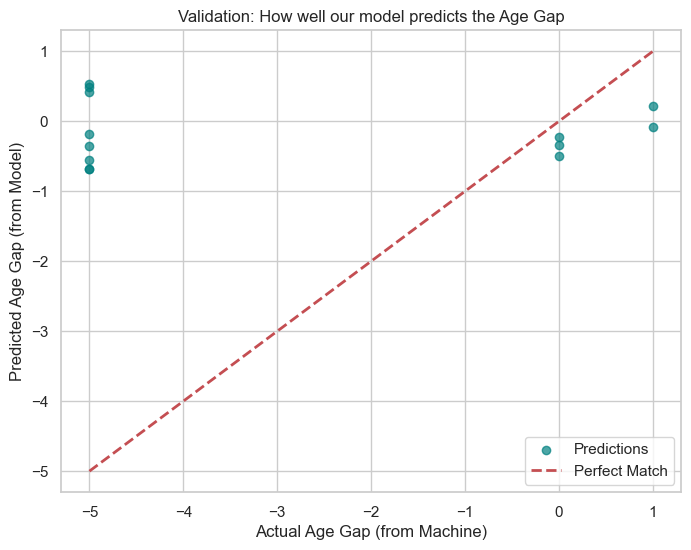

In [ ]:
# Initializing the Random Forest Regressor
# Setting max_depth to 5 to prevent overfitting on the 145 training rows
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# Training the model using the scaled training data
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Performance Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Biological Age Gap Prediction Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f} years")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (Accuracy) Score: {r2:.4f}")
print()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='teal', alpha=0.7, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Match')
plt.xlabel('Actual Age Gap (from Machine)')
plt.ylabel('Predicted Age Gap (from Model)')
plt.title('Validation: How well our model predicts the Age Gap')
plt.legend()
plt.show()

In [ ]:
# Initializing 3 different types of models
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Support Vector (SVR)": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=3, random_state=42)
}

results = []

# Looping through and testing each one
for name, md in models.items():
    md.fit(X_train_scaled, y_train)
    predictions = md.predict(X_test_scaled)
    
    current_mae = mean_absolute_error(y_test, predictions)
    current_r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": name,
        "MAE": round(current_mae, 2),
        "R2": round(current_r2, 4)
    })

df_results = pd.DataFrame(results).sort_values(by="MAE")

print("Model Comparison Results:")
print(df_results)

# Checking Feature Importance for the best linear model (Ridge)
# Tells which body parts the LINEAR logic thinks are most important
best_ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
ridge_importance = pd.DataFrame({
    'Feature': final_feature_names,
    'Weight': best_ridge.coef_
}).sort_values(by='Weight', ascending=False)

print("\nBiological Weights (Ridge Logic)")
print(ridge_importance)
# With 13 test rows, negative R² is expected for Ridge/SVR/GBR: these models
# are worse than predicting the mean on such a tiny sample, which is a statistical
# artefact of the dataset size rather than evidence of model failure.
print('
Note: negative R² values here are a statistical artefact of the 13-row test set,')
print('not evidence that these models are fundamentally broken. Expand the dataset')
print('before drawing conclusions about model quality.')

--- Model Comparison Results ---
                  Model   MAE      R2
1  Support Vector (SVR)  3.27 -1.3445
2     Gradient Boosting  3.29 -1.1544
0      Ridge Regression  3.51 -1.3939

--- Biological Weights (Ridge Logic) ---
          Feature    Weight
4     aerobicGoal  1.556297
8   muscleControl  1.371846
1           inFat  1.322622
7      fatLeftArm  0.529589
9             fat  0.488267
6              wc  0.122506
0      fatControl -0.555392
2        fatTrunk -0.792088
3   weightControl -0.971288
10  bodyShapeRisk -1.048733
5     fatRightArm -2.187948


Decision Tree MAE: 3.49 years


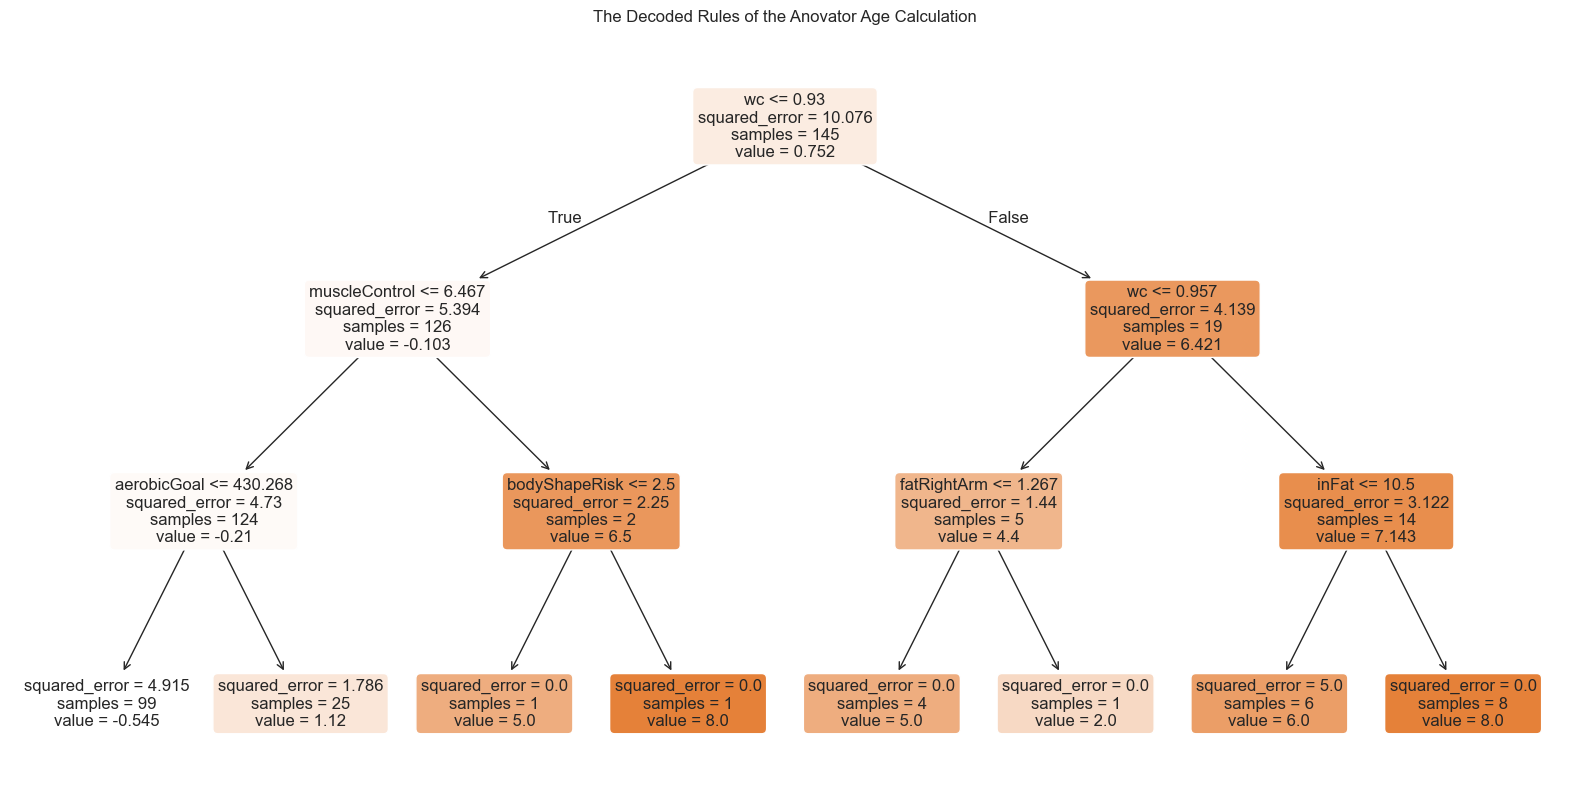


--- Text version of the aging rules ---
|--- wc <= 0.93
|   |--- muscleControl <= 6.47
|   |   |--- aerobicGoal <= 430.27
|   |   |   |--- value: [-0.55]
|   |   |--- aerobicGoal >  430.27
|   |   |   |--- value: [1.12]
|   |--- muscleControl >  6.47
|   |   |--- bodyShapeRisk <= 2.50
|   |   |   |--- value: [5.00]
|   |   |--- bodyShapeRisk >  2.50
|   |   |   |--- value: [8.00]
|--- wc >  0.93
|   |--- wc <= 0.96
|   |   |--- fatRightArm <= 1.27
|   |   |   |--- value: [5.00]
|   |   |--- fatRightArm >  1.27
|   |   |   |--- value: [2.00]
|   |--- wc >  0.96
|   |   |--- inFat <= 10.50
|   |   |   |--- value: [6.00]
|   |   |--- inFat >  10.50
|   |   |   |--- value: [8.00]



In [ ]:
# Keeping the depth shallow (3) so the rules are easy to read
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train[final_feature_names], y_train) # Using unscaled data for readability

# Evaluation
y_pred_tree = tree_model.predict(X_test[final_feature_names])
tree_mae = mean_absolute_error(y_test, y_pred_tree)
print(f"Decision Tree MAE: {tree_mae:.2f} years")

# Visualizing the "Rules of Aging"
plt.figure(figsize=(20,10))
plot_tree(tree_model, 
          feature_names=final_feature_names, 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("The Decoded Rules of the Anovator Age Calculation")
plt.show()

tree_rules = export_text(tree_model, feature_names=final_feature_names)
print("\nAging rules")
print(tree_rules)

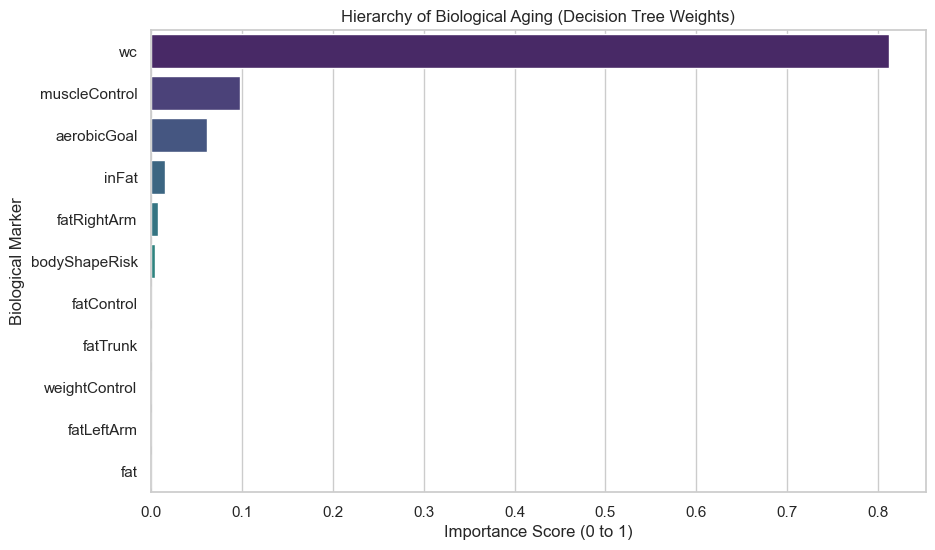

Top 3 Drivers of Biological Age in this system:
         Feature  Importance
6             wc    0.811766
8  muscleControl    0.098469
4    aerobicGoal    0.061523


In [ ]:
# Extracting feature importance from the tree
tree_importance = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=tree_importance, 
    hue='Feature', 
    palette='viridis', 
    legend=False
)
plt.title('Hierarchy of Biological Aging (Decision Tree Weights)')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Biological Marker')
plt.show()

print("Top 3 Drivers of Biological Age in this system:")
print(tree_importance.head(3))

In [ ]:
# Function to apply the rules found by the Decision Tree
def categorize_health(row):
    if row['wc'] <= 0.93:
        if row['muscleControl'] <= 6.47:
            return "Optimal (Biologically Young)"
        else:
            return "Intermediate (Muscle/Metabolic Stress)"
    else:
        return "At-Risk (Abdominal Obesity/Advanced Aging)"

df['Health_Persona'] = df.apply(categorize_health, axis=1)

# Summary of the population distribution
persona_summary = df['Health_Persona'].value_counts()
print("Distribution of Health Personas in Scanned Population:")
print(persona_summary)

# Statistical analysis of each persona group
persona_analysis = df.groupby('Health_Persona').agg({
    'score': 'mean',
    'age_gap': 'mean',
    'fat': 'mean',
    'muscle': 'mean'
}).round(2)

print("\nAverages per Persona Group:")
persona_analysis

Distribution of Health Personas in Scanned Population:
Health_Persona
Optimal (Biologically Young)                  138
At-Risk (Abdominal Obesity/Advanced Aging)     19
Intermediate (Muscle/Metabolic Stress)          1
Name: count, dtype: int64

Averages per Persona Group:


,score,age_gap,fat,muscle
Health_Persona,,,,
At-Risk (Abdominal Obesity/Advanced Aging),55.63,6.42,25.77,41.47
Intermediate (Muscle/Metabolic Stress),65.00,5.00,17.33,41.78
Optimal (Biologically Young),84.06,-0.41,15.37,47.45


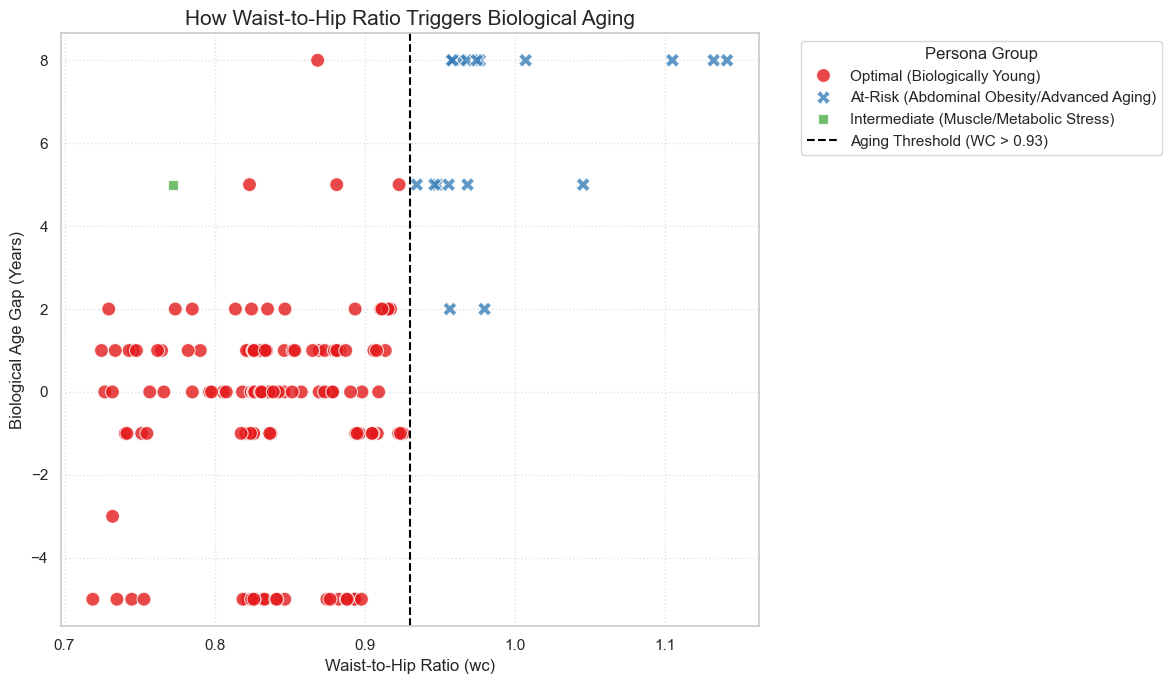

In [ ]:
plt.figure(figsize=(12, 7))

# Scatter plot of wc vs age_gap
sns.scatterplot(
    data=df, 
    x='wc', 
    y='age_gap', 
    hue='Health_Persona', 
    style='Health_Persona',
    palette='Set1', 
    s=100, 
    alpha=0.8
)

plt.axvline(x=0.93, color='black', linestyle='--', label='Aging Threshold (WC > 0.93)')

plt.title('How Waist-to-Hip Ratio Triggers Biological Aging', fontsize=15)
plt.xlabel('Waist-to-Hip Ratio (wc)', fontsize=12)
plt.ylabel('Biological Age Gap (Years)', fontsize=12)
plt.legend(title='Persona Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Calculating absolute differences (in kg) b/en left and right limbs
df['arm_muscle_diff'] = (df['muscleLeftArm'] - df['muscleRightArm']).abs()
df['leg_muscle_diff'] = (df['muscleLeftLeg'] - df['muscleRightLeg']).abs()

# Identifying "Significant Asymmetry" (e.g., more than 0.2kg for arms, 0.5kg for legs)
df['arm_imbalance'] = df['arm_muscle_diff'] > 0.2
df['leg_imbalance'] = df['leg_muscle_diff'] > 0.5

# Analyzing how imbalance affects the avg health score
imbalance_analysis = df.groupby('leg_imbalance').agg({
    'score': 'mean',
    'age_gap': 'mean',
    'id': 'count'
}).rename(columns={'id': 'count'})

print("Impact of Leg Muscle Imbalance (> 0.5kg difference) on Health Metrics:")
print(imbalance_analysis)

# Top 5 most "imbalanced" individuals in the dataset
print("\nTop 5 records with highest leg muscle asymmetry:")
df[['id', 'name', 'muscleLeftLeg', 'muscleRightLeg', 'leg_muscle_diff', 'score']].sort_values(by='leg_muscle_diff', ascending=False).head()

Impact of Leg Muscle Imbalance (> 0.5kg difference) on Health Metrics:
               score   age_gap  count
leg_imbalance                        
False           80.5  0.455128    156
True            82.0  0.000000      2

Top 5 records with highest leg muscle asymmetry:


,id,name,muscleLeftLeg,muscleRightLeg,leg_muscle_diff,score
65,75361284900345,Unknown,11.9000,13.8200,1.9200,83
64,636466451321084,Unknown,12.9000,14.6800,1.7800,81
94,667171216852665,Unknown,11.1112,11.6009,0.4897,77
2,220431535406836,Unknown,10.2354,10.5930,0.3576,88
28,845042045098585,044311,12.2547,12.5963,0.3416,98


Correlation of Postural Risks with Score and Age Gap:
(Negative correlation with score means the risk lowers the score)
                        score   age_gap
frontHeadRisk       -0.280873  0.275360
humpbackRisk        -0.190624  0.177096
side_hunchback_risk -0.190624  0.177096
spineRisk           -0.041295  0.025589
pelvisRisk           0.019609 -0.015013
postureRisk          0.050255  0.052151
kneeRisk             0.058148 -0.107146


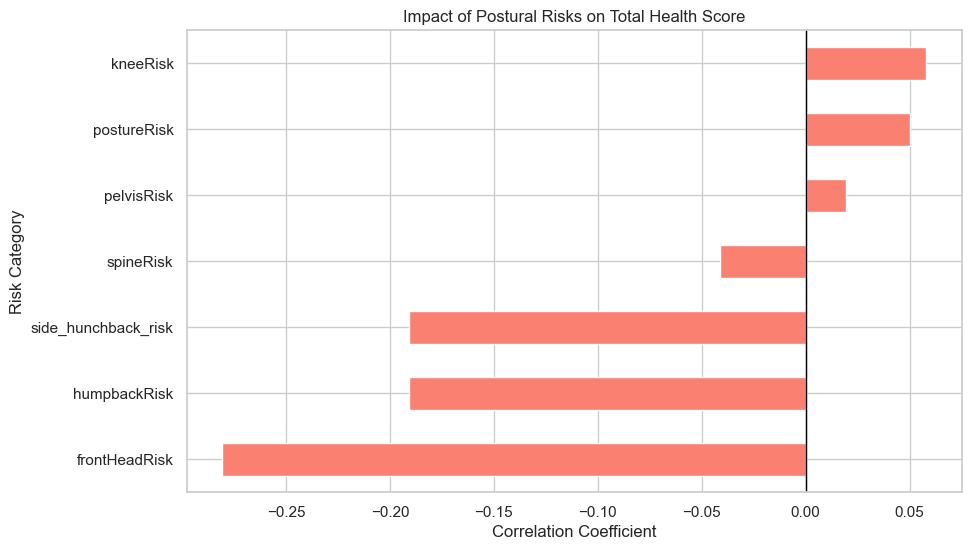

In [ ]:
# Defining the postural risk columns
posture_risk_cols = [
    'humpbackRisk', 'spineRisk', 'pelvisRisk', 
    'postureRisk', 'kneeRisk', 'frontHeadRisk', 'side_hunchback_risk'
]

# Calculating correlations b/en these risks and the main outcomes
# Using .dropna() to ensure the correlation only runs on records where risk data exists
risk_correlation = df[posture_risk_cols + ['score', 'age_gap']].corr()

# Focusing on the relationship with 'score' and 'age_gap'
impact_on_score = risk_correlation.loc[posture_risk_cols, ['score', 'age_gap']].sort_values(by='score')

print("Correlation of Postural Risks with Score and Age Gap:")
print("(Negative correlation with score means the risk lowers the score)")
print(impact_on_score)

plt.figure(figsize=(10, 6))
impact_on_score['score'].plot(kind='barh', color='salmon')
plt.title('Impact of Postural Risks on Total Health Score')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Risk Category')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

Average Postural Risk by Age Group:
               frontHeadRisk  humpbackRisk  spineRisk
age_group                                            
Youth (<18)         2.444444      1.777778   1.000000
Adult (18-50)       3.614458      2.385542   1.034091
Senior (>50)        5.000000      2.500000   1.000000


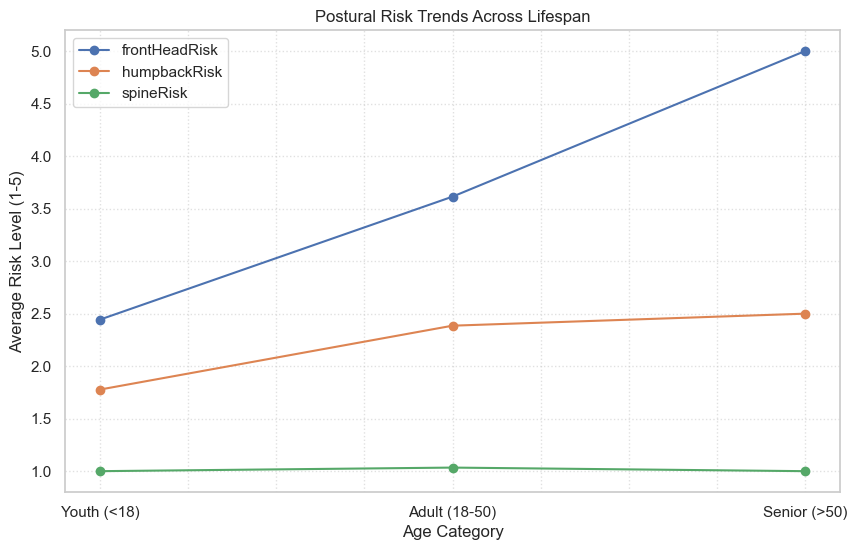

In [ ]:
# Defining age bins and labels
age_bins = [0, 18, 50, 100]
age_labels = ['Youth (<18)', 'Adult (18-50)', 'Senior (>50)']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Calculating avg risk per age group
# Using the top 3 risks identified in the previous cell
risk_trends = df.groupby('age_group', observed=True)[['frontHeadRisk', 'humpbackRisk', 'spineRisk']].mean()

print("Average Postural Risk by Age Group:")
print(risk_trends)

risk_trends.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Postural Risk Trends Across Lifespan')
plt.ylabel('Average Risk Level (1-5)')
plt.xlabel('Age Category')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Average Postural Risk by BMI Category:
                     frontHeadRisk  humpbackRisk  side_hunchback_risk
bmi_group                                                            
Underweight (<18.5)           3.00          2.00                 2.00
Normal (18.5-25)              3.12          2.17                 2.17
Overweight (25-30)            3.69          2.34                 2.34
Obese (>30)                   4.60          2.80                 2.80


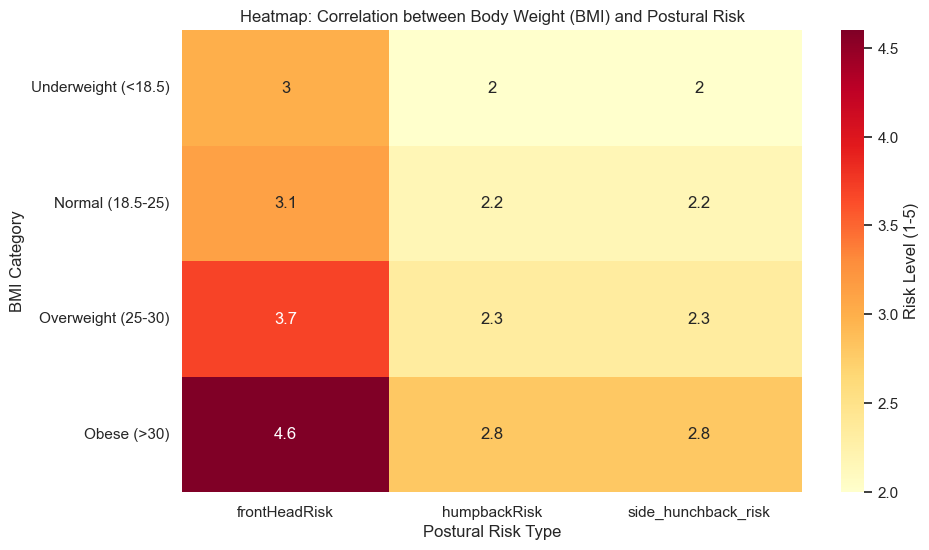

In [ ]:
# Defining BMI categories based on World Health Organization (WHO) standards
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight (<18.5)', 'Normal (18.5-25)', 'Overweight (25-30)', 'Obese (>30)']

# Creating the BMI group column
df['bmi_group'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels)

# Analyzing the top postural risks across these BMI categories
posture_by_weight = df.groupby('bmi_group', observed=True)[['frontHeadRisk', 'humpbackRisk', 'side_hunchback_risk']].mean().round(2)

print("Average Postural Risk by BMI Category:")
print(posture_by_weight)

plt.figure(figsize=(10, 6))
sns.heatmap(posture_by_weight, annot=True, cmap="YlOrRd", cbar_kws={'label': 'Risk Level (1-5)'})
plt.title('Heatmap: Correlation between Body Weight (BMI) and Postural Risk')
plt.xlabel('Postural Risk Type')
plt.ylabel('BMI Category')
plt.show()

Analysis based on 89 records with valid lung function data.

Correlation with Vital Capacity (Lung Volume):
(Negative values mean that as the factor increases, lung volume decreases)
fatTrunk        -0.168196
age             -0.084185
humpbackRisk     0.063894
height           0.403637
vitalCapacity    1.000000
Name: vitalCapacity, dtype: float64

Average Vital Capacity (ml) by Hunchback Risk Level:
humpbackRisk
1.0    3876.26
2.0    3773.94
3.0    3740.83
4.0    3989.25
5.0    4572.33
Name: vitalCapacity, dtype: float64


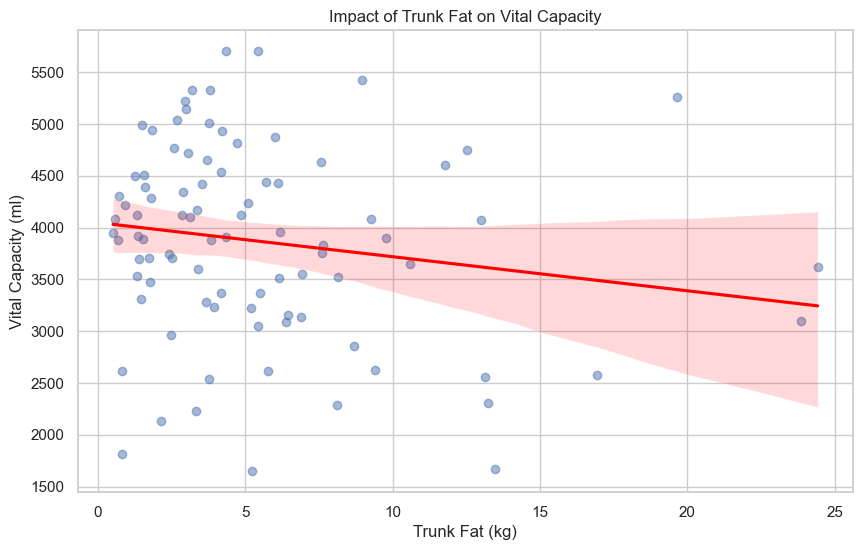

In [ ]:
# Filtering for valid Vital Capacity data (removing zeros/missing)
df_lung = df[df['vitalCapacity'] > 0].copy()

# Analyzing Vital Capacity against Hunchback Risk and Trunk Fat
lung_correlations = df_lung[['vitalCapacity', 'fatTrunk', 'humpbackRisk', 'age', 'height']].corr()['vitalCapacity'].sort_values()

print(f"Analysis based on {len(df_lung)} records with valid lung function data.")
print("\nCorrelation with Vital Capacity (Lung Volume):")
print("(Negative values mean that as the factor increases, lung volume decreases)")
print(lung_correlations)

# Categorical Analysis: Average Lung Volume per Hunchback Risk Level
lung_by_posture = df_lung.groupby('humpbackRisk')['vitalCapacity'].mean().round(2)

print("\nAverage Vital Capacity (ml) by Hunchback Risk Level:")
print(lung_by_posture)

plt.figure(figsize=(10, 6))
sns.regplot(data=df_lung, x='fatTrunk', y='vitalCapacity', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Impact of Trunk Fat on Vital Capacity')
plt.xlabel('Trunk Fat (kg)')
plt.ylabel('Vital Capacity (ml)')
plt.show()

In [ ]:
# Creating a "Simplified Health Status" based on the discoveries so far
def summarize_status(row):
    status = []
    if row['Health_Persona'] == "Optimal (Biologically Young)":
        status.append("Metabolically Young")
    else:
        status.append("Metabolic Risk Detected")
        
    if row['frontHeadRisk'] >= 4:
        status.append("High Postural Strain")
        
    if row['leg_imbalance'] == True:
        status.append("Muscle Asymmetry")
        
    return " | ".join(status)

df['Health_Summary'] = df.apply(summarize_status, axis=1)

# Re-organizing columns to show the insights first
core_insight_cols = [
    'id', 'name', 'age', 'bodyAge', 'age_gap', 'Health_Persona', 
    'Health_Summary', 'score', 'wc', 'bmi', 'fatTrunk', 'vitalCapacity'
]
remaining_cols = [c for c in df.columns if c not in core_insight_cols]
df_final_export = df[core_insight_cols + remaining_cols]

export_path = 'data/Anovator_Health_Intelligence_Dataset.csv'
df_final_export.to_csv(export_path, index=False)

print(f"Final Enriched Dataset saved to: {export_path}")
print(f"Total Rows: {len(df_final_export)}")
print(f"Total Insights/Features: {len(df_final_export.columns)}")

print("\nSample Health Intelligence Profiles:")
df_final_export[['name', 'age_gap', 'Health_Persona', 'Health_Summary']].head(10)

--- FINAL PROJECT CONSOLIDATION ---
Final Enriched Dataset saved to: data/Anovator_Health_Intelligence_Dataset.csv
Total Rows: 158
Total Insights/Features: 125

Sample Health Intelligence Profiles:


,name,age_gap,Health_Persona,Health_Summary
0,Unknown,1,Optimal (Biologically Young),Metabolically Young
1,Unknown,1,Optimal (Biologically Young),Metabolically Young | High Postural Strain
2,Unknown,-1,Optimal (Biologically Young),Metabolically Young | High Postural Strain
3,880224,-5,Optimal (Biologically Young),Metabolically Young
4,950318,-5,Optimal (Biologically Young),Metabolically Young
5,090703,0,Optimal (Biologically Young),Metabolically Young
6,120612,1,Optimal (Biologically Young),Metabolically Young
7,104921,1,Optimal (Biologically Young),Metabolically Young
8,104614,1,Optimal (Biologically Young),Metabolically Young | High Postural Strain
9,095215,0,Optimal (Biologically Young),Metabolically Young
